# Table of Contents
* [1. Fast Generator](#generator)
* [2. Logic Visualizer](#visualizer)
* [3. Output Preview](#preview)

### 🧠 ARC Logic Engine

This tool decodes ARC-AGI patterns into human-readable rules to help you group similar tasks and design ONNX architectures faster.

---

### Usage
* **Group Tasks:** Find all "Symmetry" or "Rotation" tasks to reuse architectures.
* **Identify Difficulty:** See exactly where the LLM fails to prioritize manual work.
* **Architecture Mapping:** Use the logic to decide between Conv2D, Pooling, or Tiling layers.

### Next
* **Keyword-to-Operator Mapping:** Automatically link main rule words (e.g., "Rotate," "Mirror," "Scale") to specific low-cost ONNX operators to automate model design.
* **Semantic Embedding:** Use NLP embeddings to cluster tasks by rule similarity, allowing one optimized neural architecture to be reused for dozens of related problems.

## ⚡ Fast Generator <a id="generator"></a>

In [1]:
import json, os, glob, time, csv
from openai import OpenAI
from kaggle_secrets import UserSecretsClient

# --- Configuration ---
START_TASK, END_TASK = 1, 100
BATCH_SIZE = 1  # Keeping it at 1 ensures the model focuses deeply on one specific logic
JSON_OUTPUT = '/kaggle/working/arc_explanations.json'
CSV_OUTPUT = '/kaggle/working/arc_explanations.csv'

# --- API Setup ---
user_secrets = UserSecretsClient()
client = OpenAI(
    api_key=user_secrets.get_secret("deepseek_api_key"),
    base_url="https://api.deepseek.com"
)

def format_grid(grid):
    return "\n".join([f"R{i}: {row}" for i, row in enumerate(grid)])

def save_dual_outputs(data_dict):
    with open(JSON_OUTPUT, 'w') as f:
        json.dump(data_dict, f, indent=2)
    with open(CSV_OUTPUT, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['Task_ID', 'Short_Rule'])
        for tid in sorted(data_dict.keys()):
            writer.writerow([tid, data_dict[tid]])

# --- Engine ---
dataset_dir = '/kaggle/input/competitions/neurogolf-2026'
all_files = sorted(glob.glob(os.path.join(dataset_dir, "task*.json")))
explanations = {}

target_files = [f for f in all_files if START_TASK <= int(''.join(filter(str.isdigit, os.path.basename(f)))) <= END_TASK]

print(f"🚀 Processing {len(target_files)} tasks with Enhanced Prompting...")

for i in range(0, len(target_files), BATCH_SIZE):
    batch_files = target_files[i : i + BATCH_SIZE]
    
    # --- The "Logic First" Prompt ---
    prompt = """Analyze the transformation logic between the Input and Output grids. 
    Focus on: 
    1. Objects (groups of same-colored pixels) and their movement or scaling.
    2. Color changes (which color replaces which).
    3. Geometry (rotation, reflection, or symmetry).
    
    Provide a specific 2-3 sentence rule that works for ALL examples. Make rule specific'
    
    Return a JSON object where keys are Task IDs and values are the specific rule string."""
    
    for f in batch_files:
        tid = os.path.basename(f).replace('.json','')
        task_data = json.load(open(f))
        prompt += f"\n\n### TASK: {tid}\n"
        for idx, pair in enumerate(task_data['train']):
            prompt += f"--- Example {idx} ---\nIN:\n{format_grid(pair['input'])}\nOUT:\n{format_grid(pair['output'])}\n"

    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model="deepseek-chat",
                messages=[
                    {"role": "system", "content": "You are a world-class ARC-AGI pattern recognizer. You identify exact spatial and logical transformations. Output ONLY valid JSON."},
                    {"role": "user", "content": prompt}
                ],
                response_format={'type': 'json_object'}
            )
            
            batch_results = json.loads(response.choices[0].message.content)
            explanations.update(batch_results)
            save_dual_outputs(explanations)
            print(f"✅ Decoded: {list(batch_results.keys())}")
            break
        except Exception as e:
            print(f"⚠️ Retry: {e}")
            time.sleep(2)

print(f"🎉 Processed and saved to {JSON_OUTPUT} and {CSV_OUTPUT}")

🚀 Processing 100 tasks with Enhanced Prompting...
✅ Decoded: ['task001']
✅ Decoded: ['task002']
✅ Decoded: ['task003']
✅ Decoded: ['task004']
✅ Decoded: ['task005']
✅ Decoded: ['task006']
✅ Decoded: ['task007']
✅ Decoded: ['task008']
✅ Decoded: ['task009']
✅ Decoded: ['task010']
✅ Decoded: ['task011']
✅ Decoded: ['task012']
✅ Decoded: ['task013']
✅ Decoded: ['task014']
✅ Decoded: ['task015']
✅ Decoded: ['task016']
✅ Decoded: ['task017']
✅ Decoded: ['task018']
✅ Decoded: ['task019']
✅ Decoded: ['task020']
✅ Decoded: ['task021']
✅ Decoded: ['task022']
✅ Decoded: ['task023']
✅ Decoded: ['task024']
✅ Decoded: ['task025']
✅ Decoded: ['task026']
✅ Decoded: ['task027']
✅ Decoded: ['task028']
✅ Decoded: ['task029']
✅ Decoded: ['task030']
✅ Decoded: ['task031']
✅ Decoded: ['task032']
✅ Decoded: ['task033']
✅ Decoded: ['task034']
✅ Decoded: ['task035']
✅ Decoded: ['task036']
✅ Decoded: ['task037']
✅ Decoded: ['task038']
✅ Decoded: ['task039']
✅ Decoded: ['task040']
✅ Decoded: ['task041']
✅ Decod

## 📊 Output Preview <a id="preview"></a>

In [2]:
import pandas as pd
import json

# 1. Display CSV shortly
print("📊 CSV PREVIEW (Short Rules):")
try:
    df = pd.read_csv('/kaggle/working/arc_explanations.csv')
    display(df.head(10)) # Shows first 10 rows
except Exception as e:
    print(f"CSV not found: {e}")

print("\n" + "="*50 + "\n")

# 2. Display JSON shortly
print("📄 JSON SNIPPET (First 3 entries):")
try:
    with open('/kaggle/working/arc_explanations.json', 'r') as f:
        data = json.load(f)
        # Get only the first 3 keys to keep it short
        short_data = {k: data[k] for k in list(data.keys())[:3]}
        print(json.dumps(short_data, indent=2))
except Exception as e:
    print(f"JSON not found: {e}")

📊 CSV PREVIEW (Short Rules):


,Task_ID,Short_Rule
0,task001,The input 3x3 grid is tiled into a 3x3 block p...
1,task002,"For each cell in the input grid, if the cell i..."
2,task003,The transformation duplicates the input grid v...
3,task004,For each object (connected group of same-color...
4,task005,For each object (connected group of same-color...
5,task006,The output grid is a 3x3 matrix derived from t...
6,task007,The output grid is a 7x7 tiling of a repeating...
7,task008,For each distinct object (connected group of s...
8,task009,Identify all 2x2 blocks of the same non-zero c...
9,task010,"In the input grid, each column containing at l..."




📄 JSON SNIPPET (First 3 entries):
{
  "task001": "The input 3x3 grid is tiled into a 3x3 block pattern in the output 9x9 grid, where each block is a copy of the input grid. The input grid is placed in the output such that its top-left corner aligns with positions (0,0), (0,3), (0,6), (3,0), (3,3), (3,6), (6,0), (6,3), and (6,6) in the output grid, creating a 3x3 tiling of the input pattern. All colors and positions within each tile are preserved exactly as in the input, with no scaling, rotation, reflection, or color changes applied.",
  "task002": "For each cell in the input grid, if the cell is color 0 (background) and is adjacent (including diagonally) to at least two cells of color 3 that are themselves adjacent to each other (forming a connected group of 3s), change that cell to color 4. All other cells remain unchanged.",
  "task003": "The transformation duplicates the input grid vertically by appending it to itself, creating an output grid with double the rows. All pixels with

## 🎨 Logic Visualizer <a id="visualizer"></a>


==================== task001 ====================
RULE: The input 3x3 grid is tiled into a 3x3 block pattern in the output 9x9 grid, where each block is a copy of the input grid. The input grid is placed in the output such that its top-left corner aligns with positions (0,0), (0,3), (0,6), (3,0), (3,3), (3,6), (6,0), (6,3), and (6,6) in the output grid, creating a 3x3 tiling of the input pattern. All colors and positions within each tile are preserved exactly as in the input, with no scaling, rotation, reflection, or color changes applied.



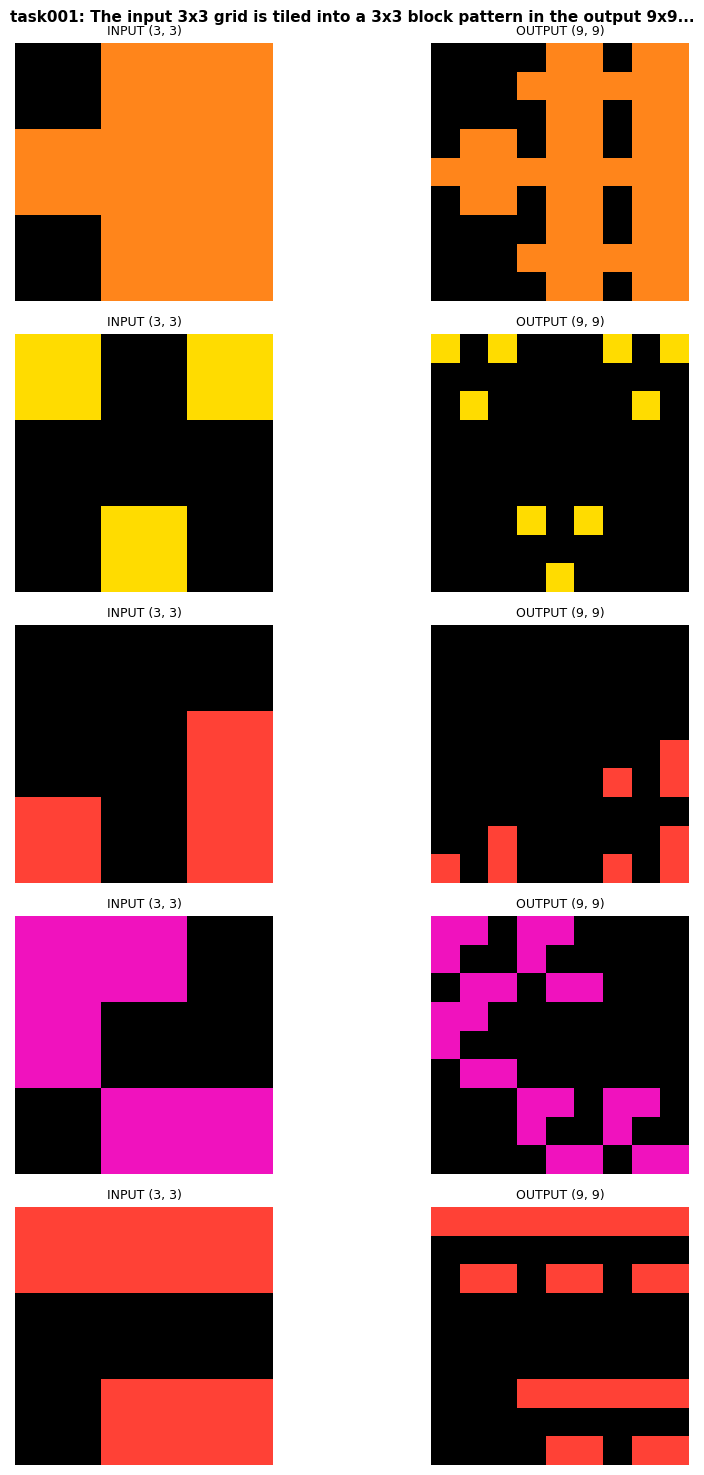


==================== task002 ====================
RULE: For each cell in the input grid, if the cell is color 0 (background) and is adjacent (including diagonally) to at least two cells of color 3 that are themselves adjacent to each other (forming a connected group of 3s), change that cell to color 4. All other cells remain unchanged.



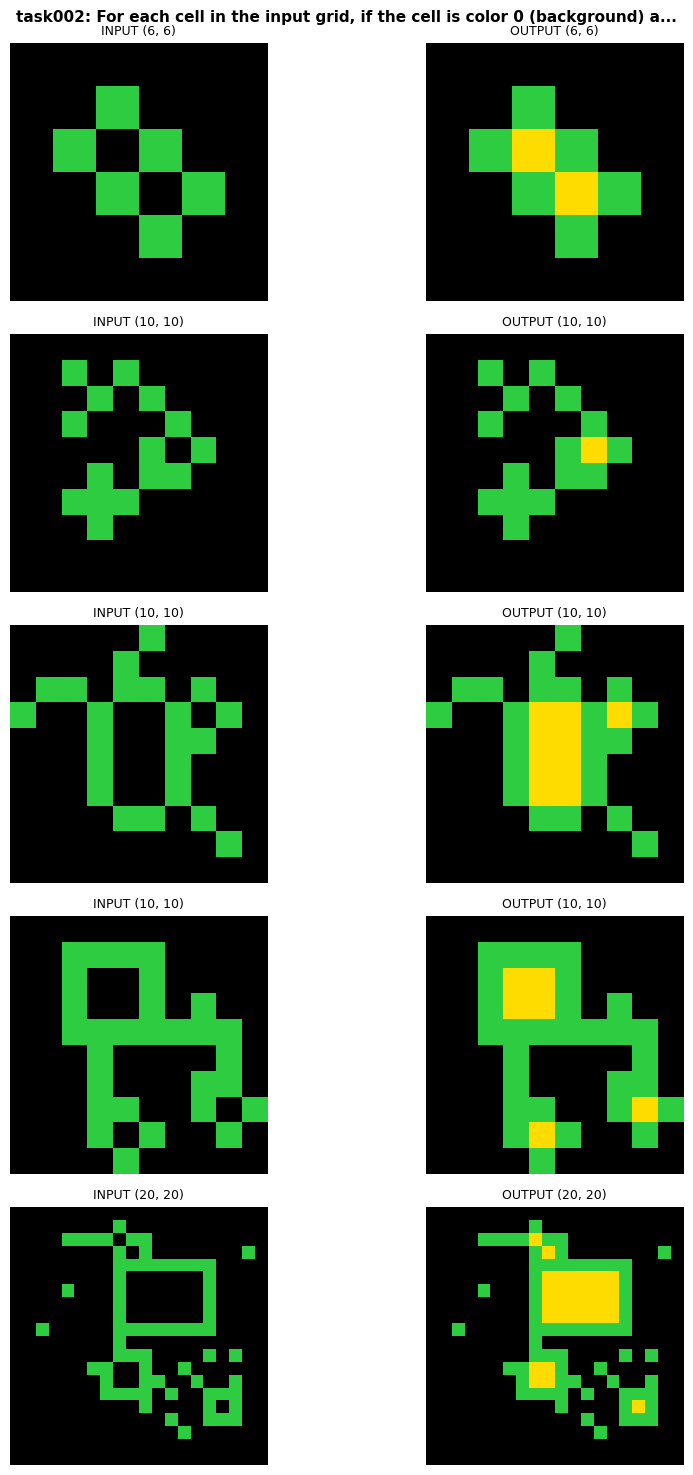


==================== task003 ====================
RULE: The transformation duplicates the input grid vertically by appending it to itself, creating an output grid with double the rows. All pixels with color 1 in the input are changed to color 2 in the output, while color 0 remains unchanged. No other geometric changes such as rotation or reflection occur.



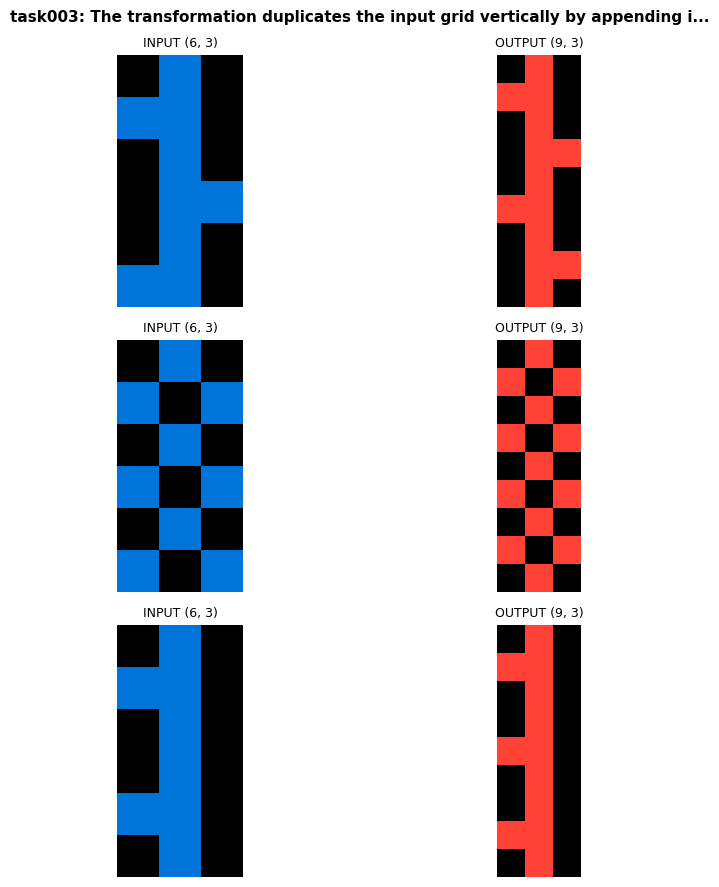


==================== task004 ====================
RULE: For each object (connected group of same-colored non-zero pixels), shift it one column to the right, preserving its shape and color. If shifting causes overlap with another object or grid boundary, stop at the nearest valid position without overlapping or exceeding the grid.



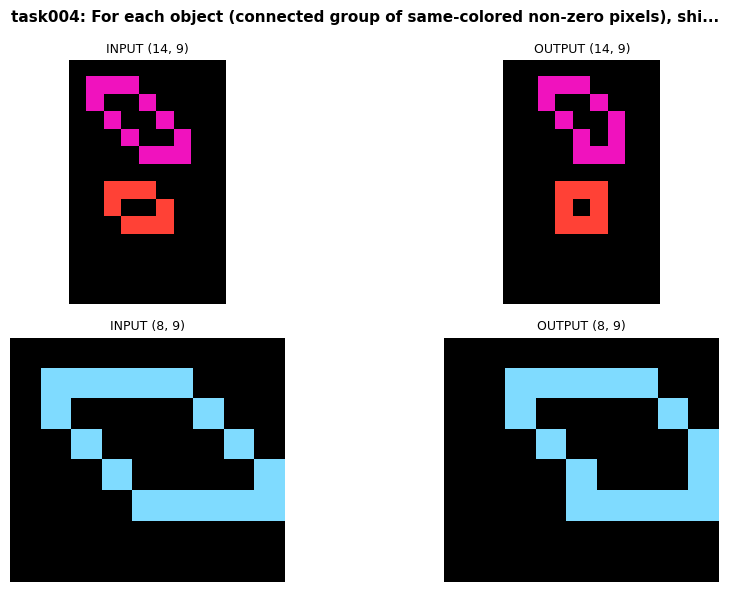


==================== task005 ====================
RULE: For each object (connected group of same-colored non-zero pixels) in the input, create a 3x3 pattern centered on the object's bounding box, where the pattern is a 3x3 grid with the object's color in all positions except the center if the object is a single pixel or has a hole, otherwise fill entirely. Then, replicate this pattern horizontally to the right, starting from the object's right edge, filling empty columns with zeros between patterns, and stop at the grid boundary. Objects are preserved in their original positions without movement or scaling, and no color changes occur.



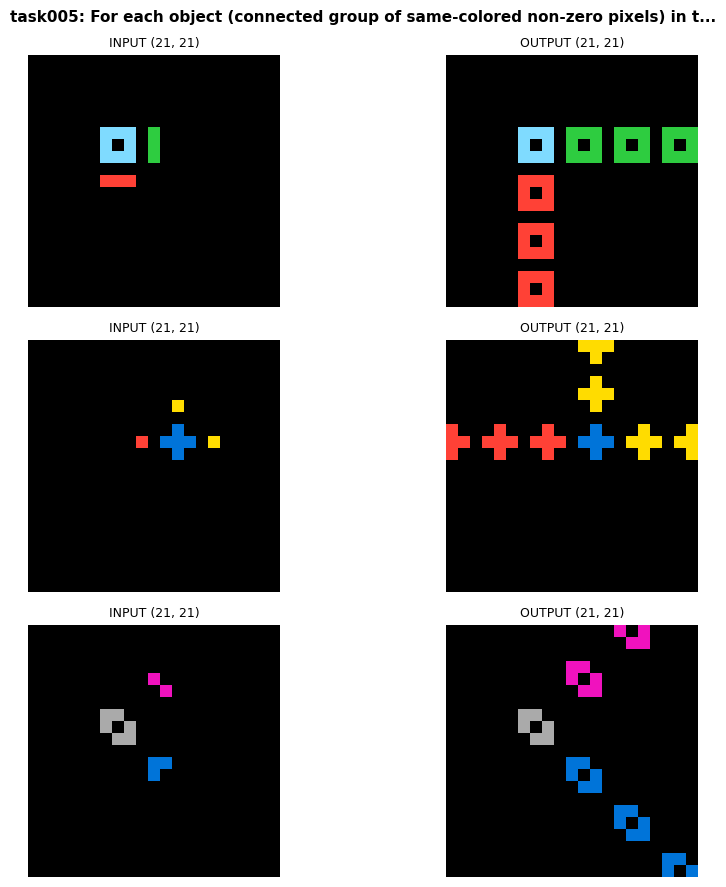


==================== task006 ====================
RULE: The output grid is a 3x3 matrix derived from the input grid by: 1) Isolate the left 3x3 subgrid (first three columns) and right 3x3 subgrid (last three columns) from the input's 7 columns, ignoring the middle column (index 3, color 5). 2) For each cell position (i,j) in the output, if the left subgrid cell at (i,j) is 1 and the right subgrid cell at (i,j) is 1, set output to 2; otherwise, set output to 0.



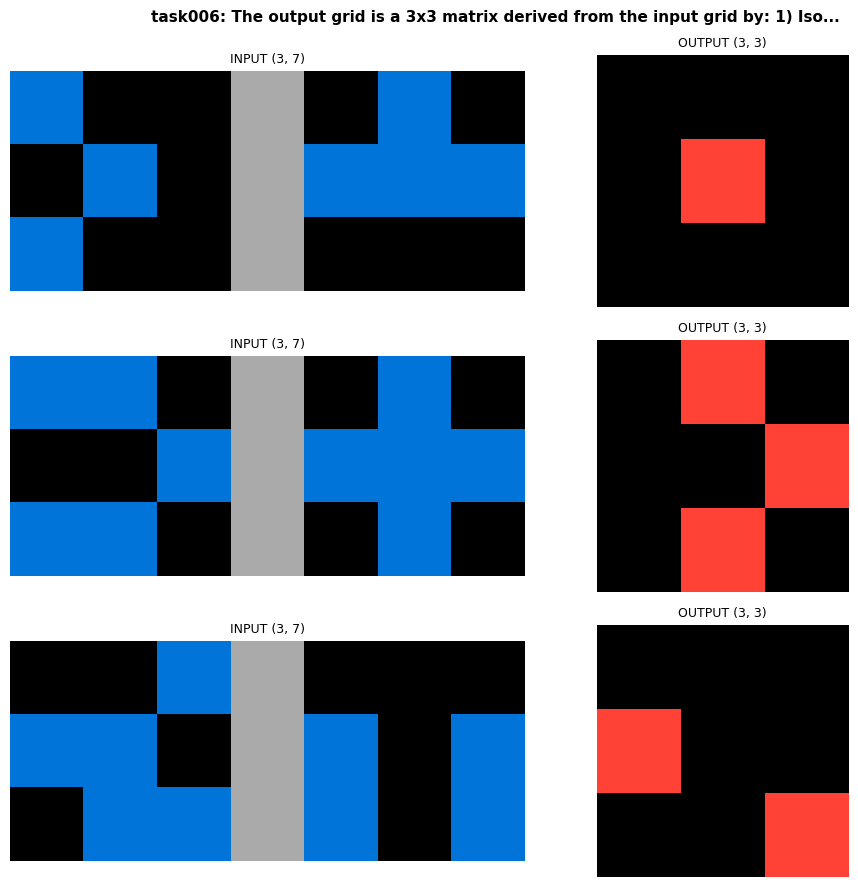


==================== task007 ====================
RULE: The output grid is a 7x7 tiling of a repeating 3-element sequence derived from the input. The sequence is extracted from the input by reading non-zero values along the main diagonal from top-left to bottom-right, starting from the first non-zero encountered, and wrapping around if needed. This sequence is then tiled across the entire grid, with each row offset by one position to the left compared to the row above, creating a diagonal pattern. Specifically, for each example: in Example 0, the sequence is [2,8,3]; in Example 1, it's [2,4,1]; in Example 2, it's [4,8,3].



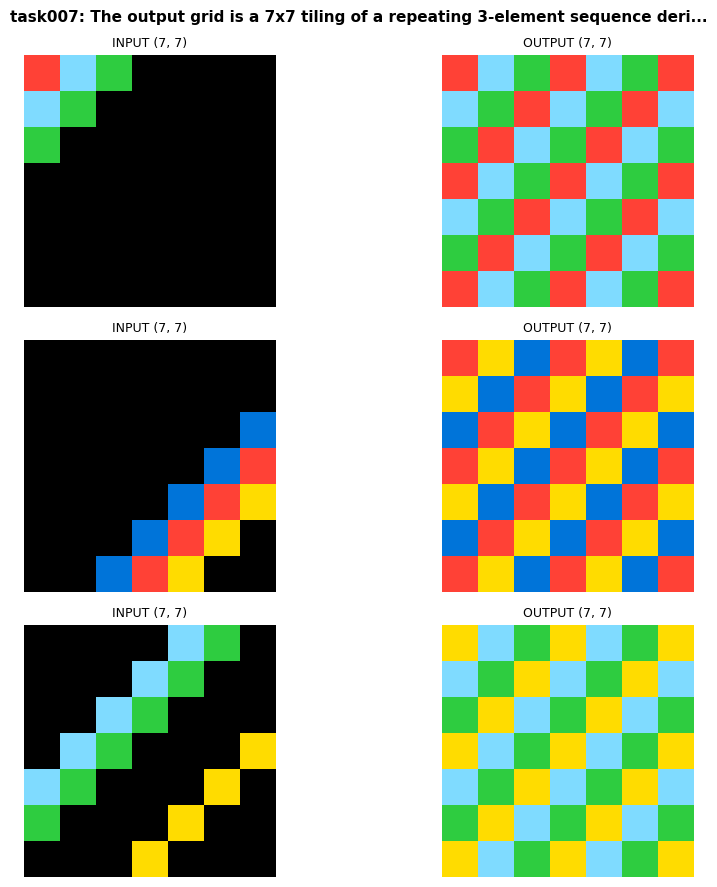


==================== task008 ====================
RULE: For each distinct object (connected group of same-colored non-zero pixels) in the input, move it vertically downward until it either contacts another object or reaches the bottom of the grid, without changing its shape, color, or relative horizontal position. Objects move independently and stop upon collision with any other object or the grid boundary.



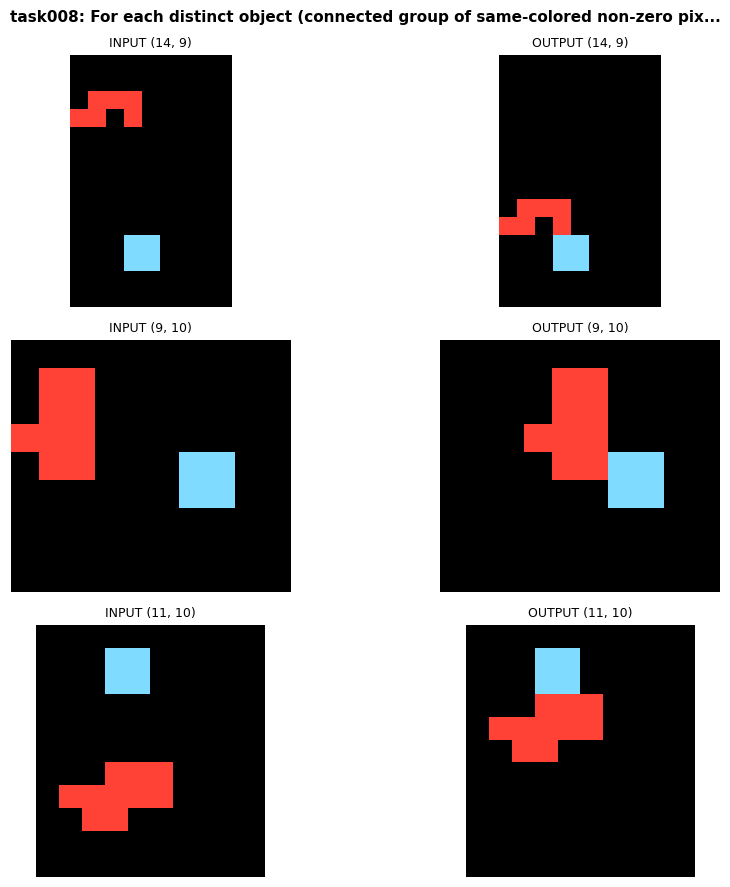


==================== task009 ====================
RULE: Identify all 2x2 blocks of the same non-zero color that are adjacent horizontally or vertically to a cell with the same color as the grid's border (the color of the continuous horizontal lines, e.g., 8 in Example 0, 1 in Example 1, 4 in Example 2). For each such 2x2 block, copy its color to all cells in the same row that are between the block and the next occurrence of the border color to the right, but only within the same row segment bounded by border-colored cells, and apply this to both rows of the block. No other changes occur.



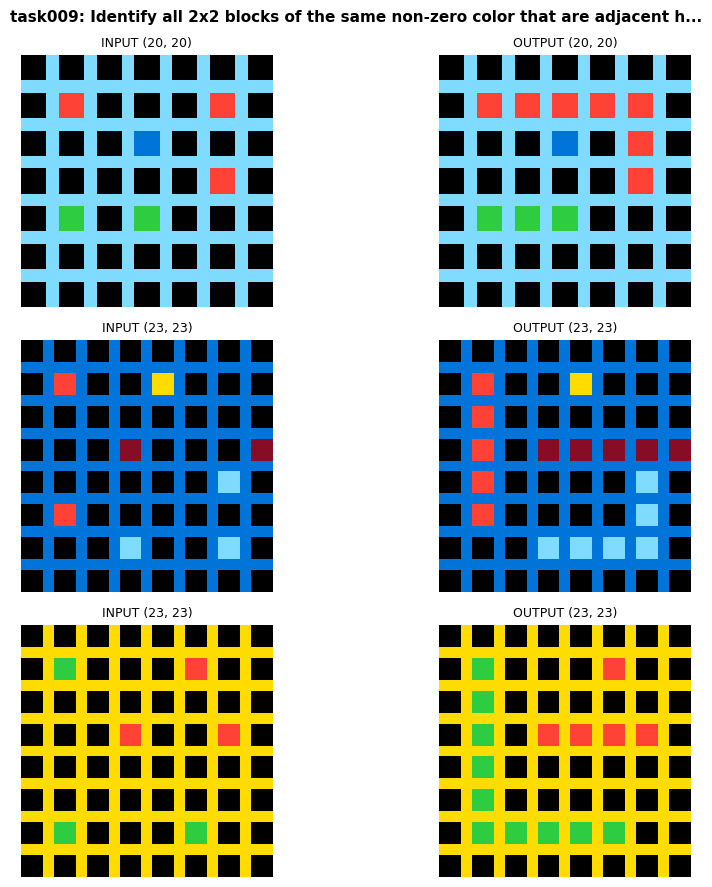


==================== task010 ====================
RULE: In the input grid, each column containing at least one pixel of color 5 is transformed into a new column in the output grid. The new column is placed in the same position as the original column, and within that column, each pixel that was color 5 is replaced with a new color: starting from the topmost such column (leftmost if multiple columns start at the same row), assign colors 1, 2, 3, 4 sequentially to the columns based on the order of their topmost non-zero pixel from left to right, with all pixels in a column taking that column's assigned color, while preserving the positions of non-5 pixels as 0.



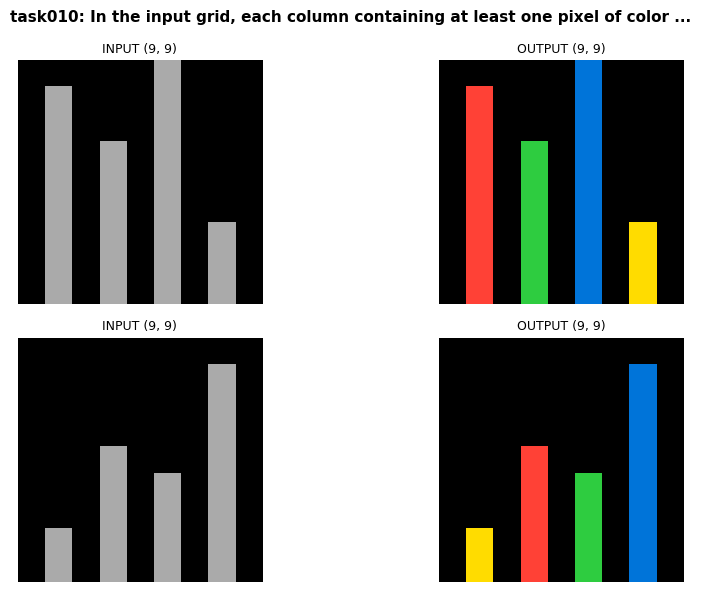


==================== task011 ====================
RULE: The grid is divided into 3x3 blocks (excluding the central column of color 5). For each block, identify the most frequent non-zero color in the input block; if there is a tie or no non-zero colors, use color 0. In the output, fill the entire block with that color, while preserving the central column of color 5 unchanged.



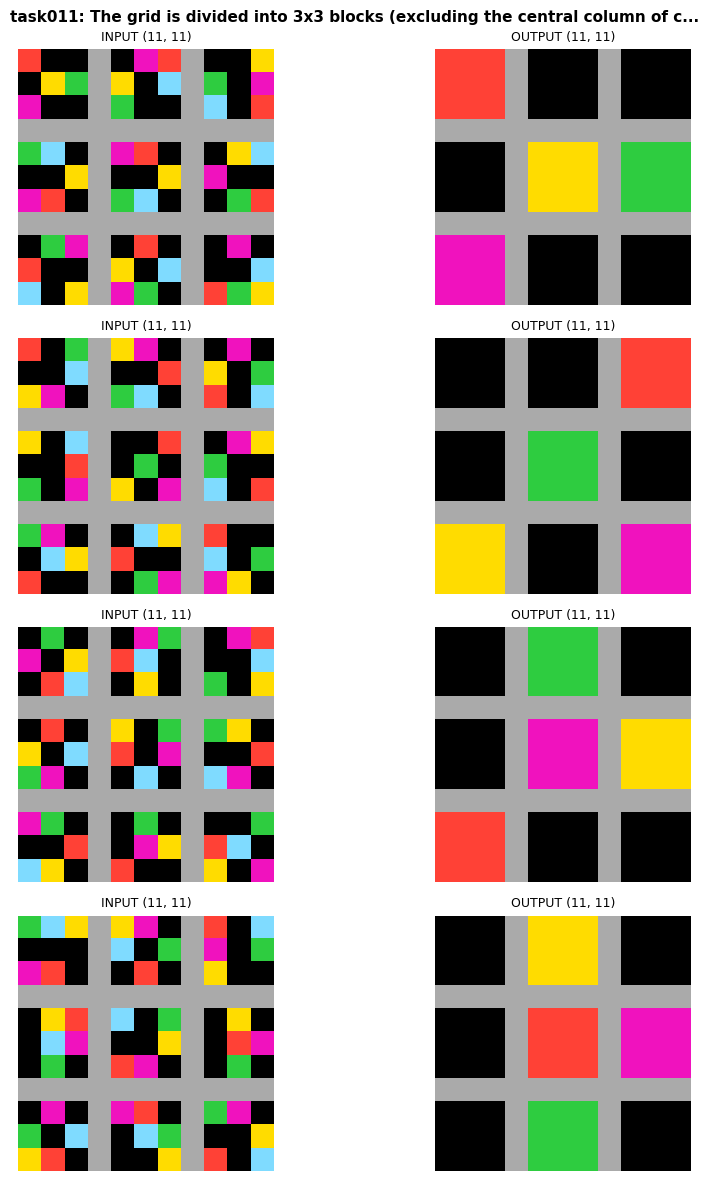


==================== task012 ====================
RULE: For each cross pattern (center color C, surrounding color S) in the input, create a larger cross pattern in the output: place a cross of color S at the same center, and add a cross of color C at each of the four diagonal positions relative to the center (i.e., offsets of (-1,-1), (-1,1), (1,-1), (1,1)), with the center color of these diagonal crosses being S and the surrounding color being C. The output is the union of all such expanded patterns from the input.



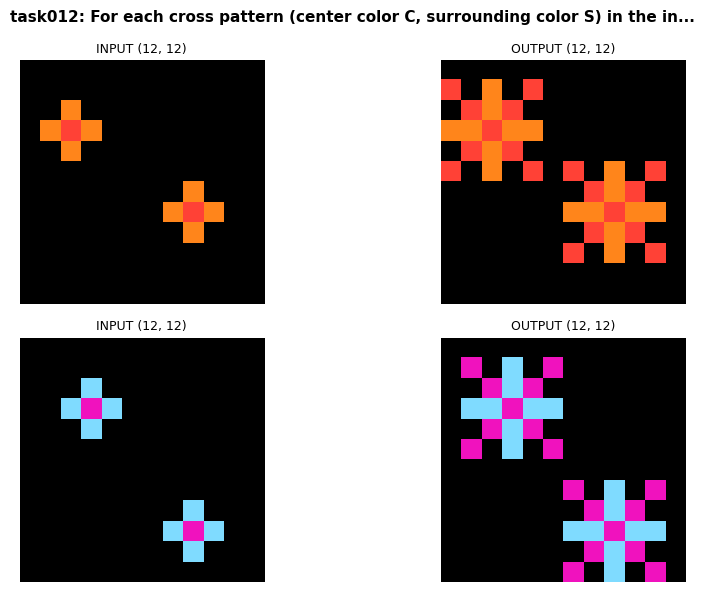


==================== task013 ====================
RULE: Identify all non-zero colored pixels in the input grid. For each such pixel, copy its color across the entire row where it appears, starting from its original column and repeating the pattern of that color and any other non-zero colors in the same row, alternating if multiple colors are present, to fill the row. If only one non-zero color exists in a row, fill the entire row with that color. This creates horizontal stripes of the colors, preserving their vertical positions and order from the input.



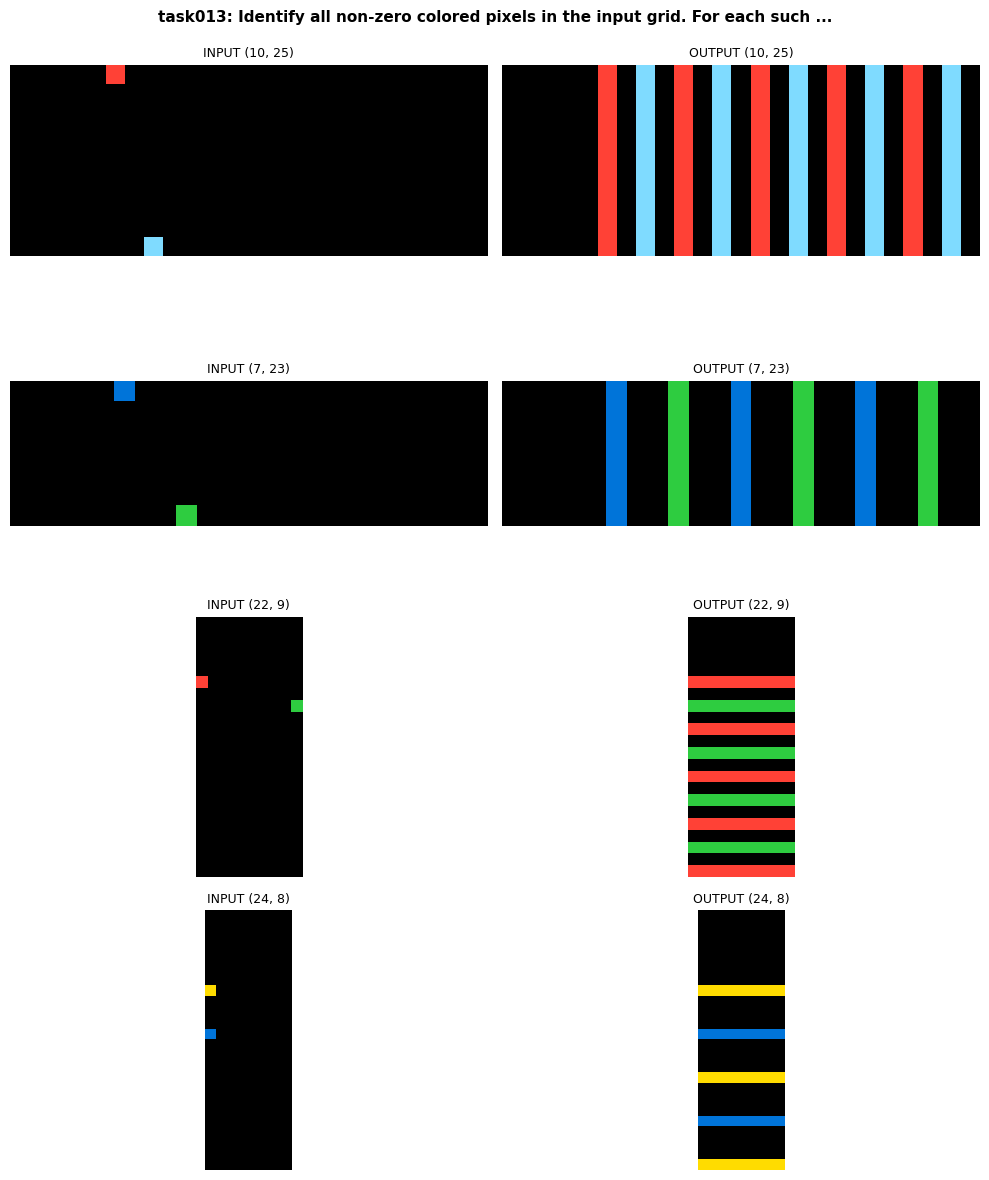


==================== task014 ====================
RULE: The transformation extracts the bottom-right block of non-zero pixels from the input grid, where the block is defined as the contiguous region starting from the first row that contains a non-zero pixel after a sequence of all-zero rows, and extending to the last row and column of the grid, with all-zero rows and columns trimmed from the edges. The colors remain unchanged, and no geometric operations like rotation or reflection are applied.



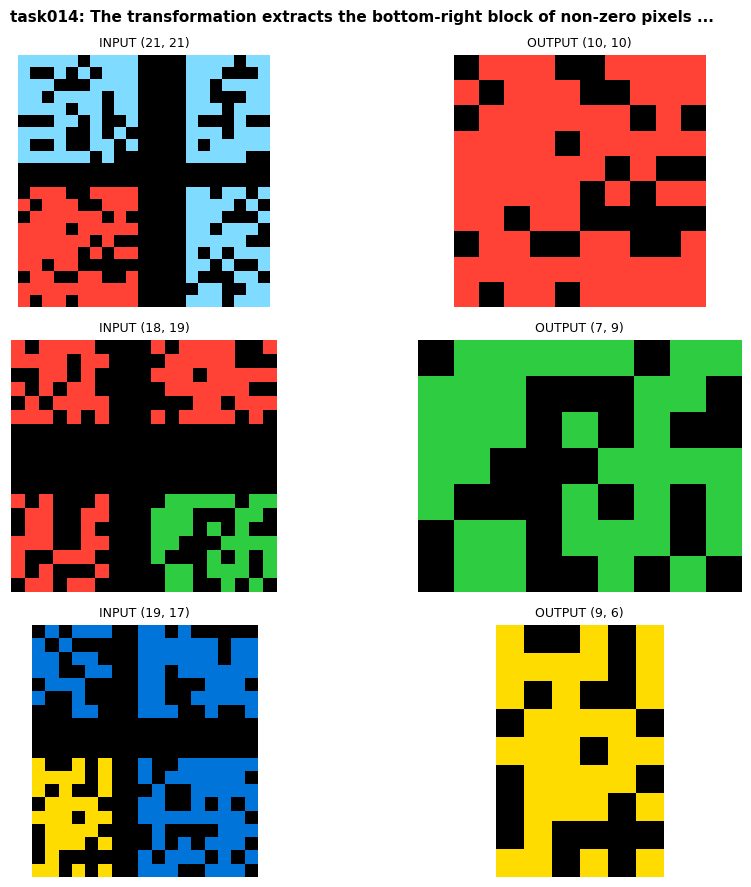


==================== task015 ====================
RULE: For each color-1 pixel in the input, place color-7 pixels in its four orthogonal adjacent cells (up, down, left, right) in the output, but only if those cells are empty in the input and not overlapping with other color-7 placements. For each color-2 pixel in the input, place color-4 pixels in its four diagonal adjacent cells (top-left, top-right, bottom-left, bottom-right) in the output, but only if those cells are empty in the input and not overlapping with other color-4 placements. All other pixels remain unchanged from input to output.



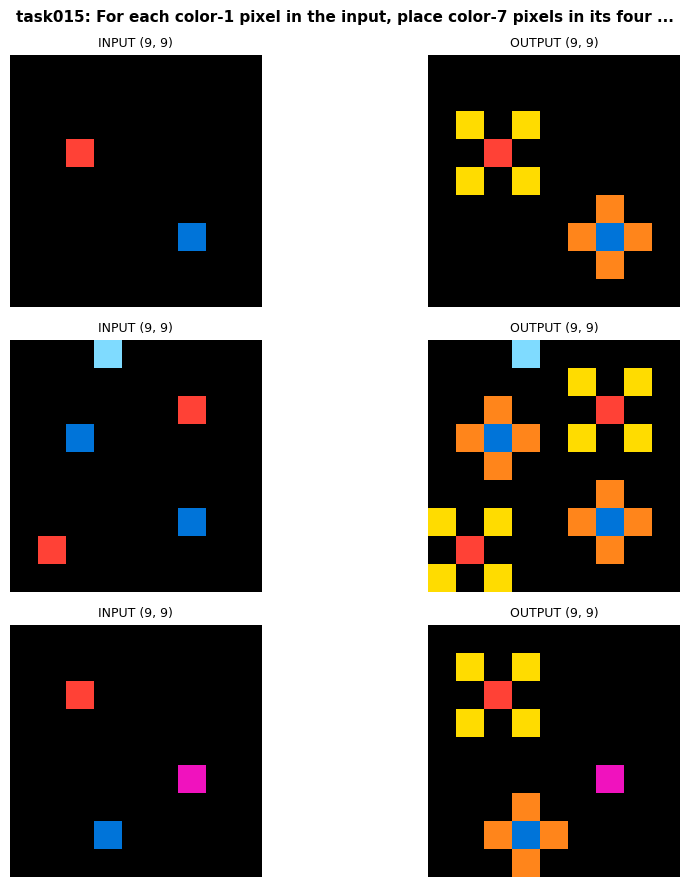


==================== task016 ====================
RULE: For each column in the input grid, replace all identical values in that column with a new value according to a fixed mapping: 1→4, 2→6, 3→4, 4→3, 5→1, 6→2, 8→9, 9→8. The output grid maintains the same dimensions and row uniformity as the input.



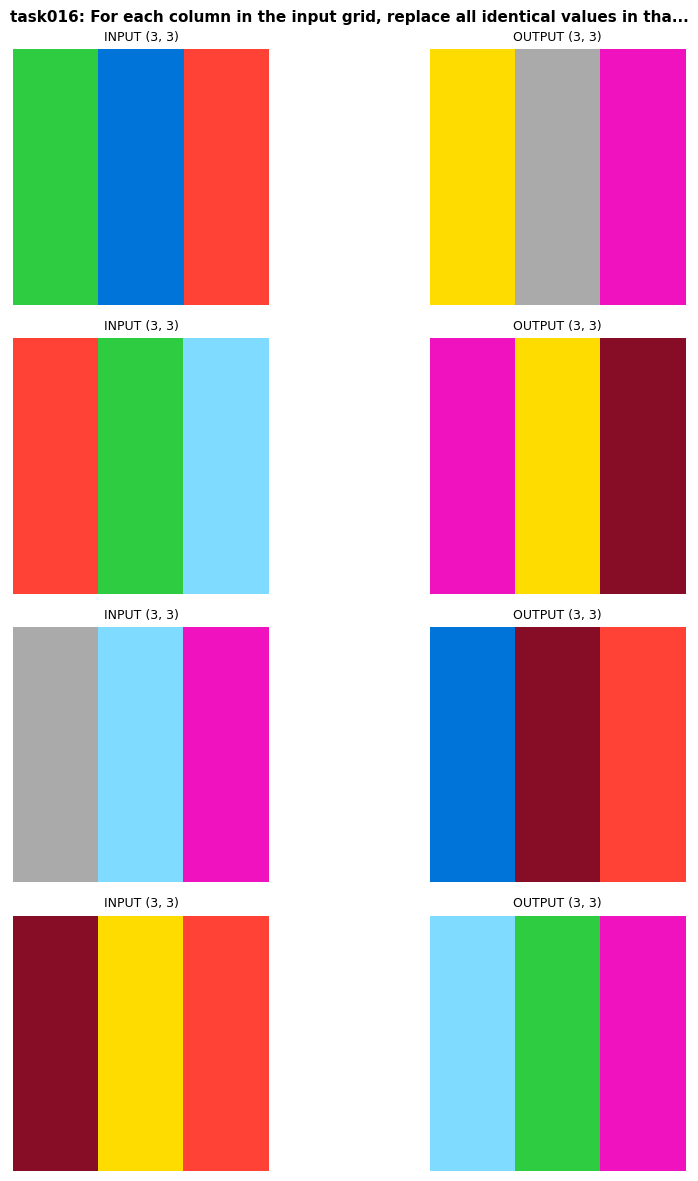


==================== task017 ====================
RULE: The transformation replaces all zeros (0) in the input grid with the nearest non-zero value from the same row, scanning left to right and right to left to fill gaps, without changing any non-zero values or altering the grid's dimensions, resulting in a complete pattern without holes.



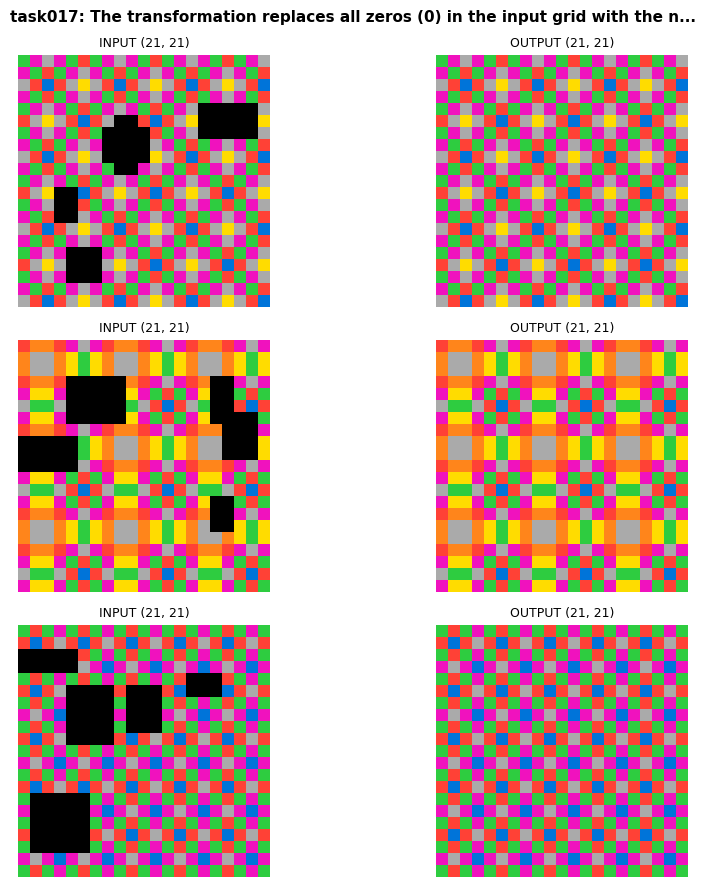


==================== task018 ====================
RULE: For each distinct object (connected group of non-zero pixels) in the input, identify its bounding box. Move the entire object vertically downward until it aligns with the bottommost row of the grid or another object, preserving its shape and colors. If multiple objects are in the same column, stack them from bottom to top in the order they appear in the input, with no gaps between objects.



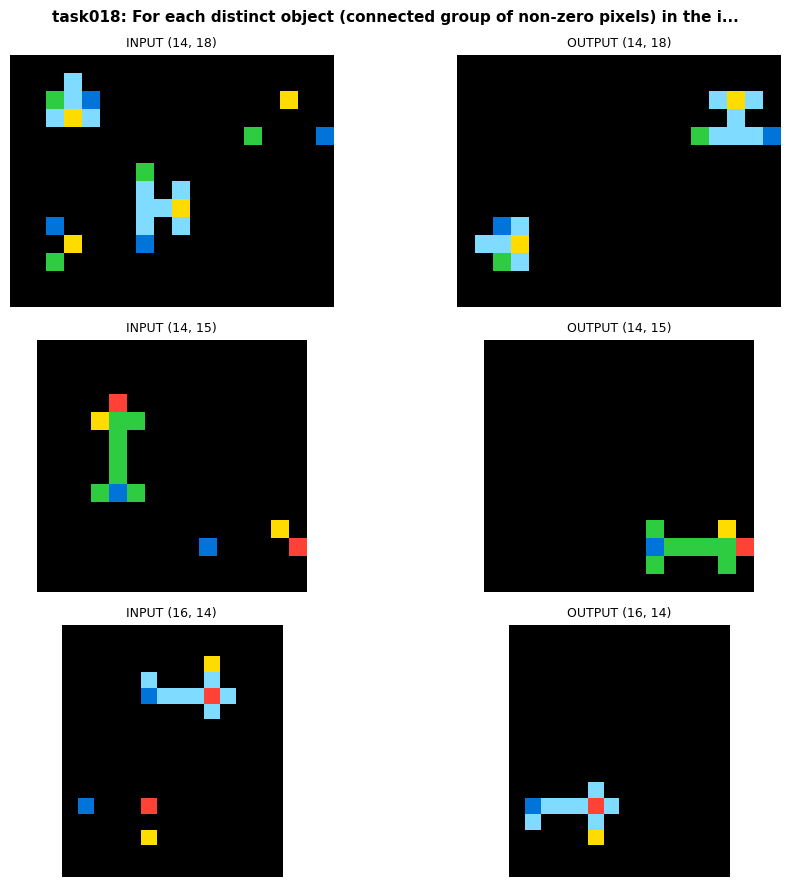


==================== task019 ====================
RULE: For each non-zero colored pixel in the input grid, create a 2x2 block in the output: place the original color at the top-left, fill the rest with color 8, and replicate the input grid's pattern by tiling these blocks horizontally and vertically, doubling the dimensions. Specifically, the output width is twice the input width, and the output height is twice the input height, with each input pixel expanded into a 2x2 block where the original color (if not zero) is at (0,0) of the block and color 8 fills the other three positions; zero input pixels become all zeros in their 2x2 block.



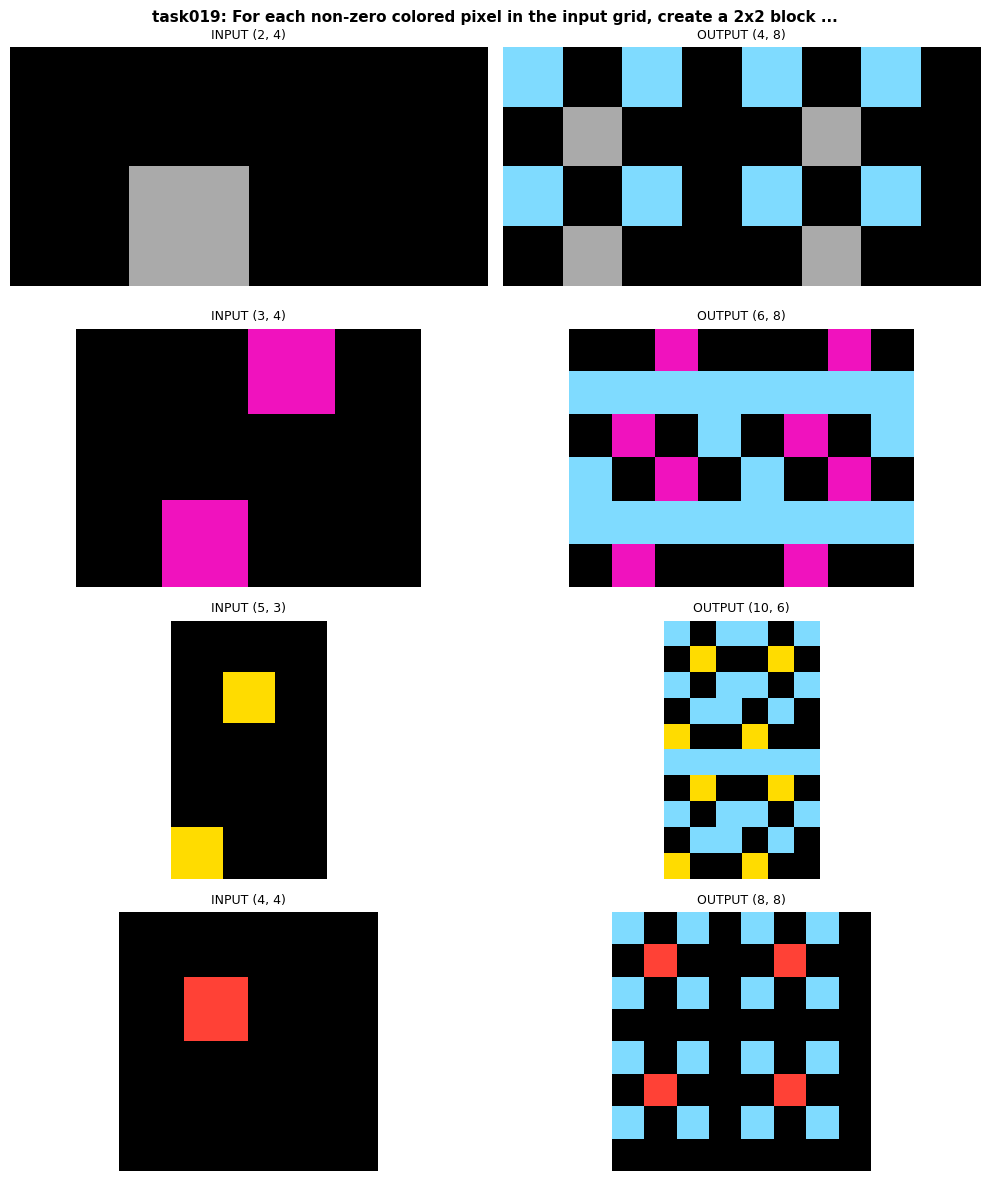


==================== task020 ====================
RULE: For each object defined as a connected group of same-colored non-zero pixels, copy it to the row directly below its current position if that row is empty (all zeros) and the object is not at the bottom of the grid. The copy retains the same color and shape, and no other changes occur to the grid.



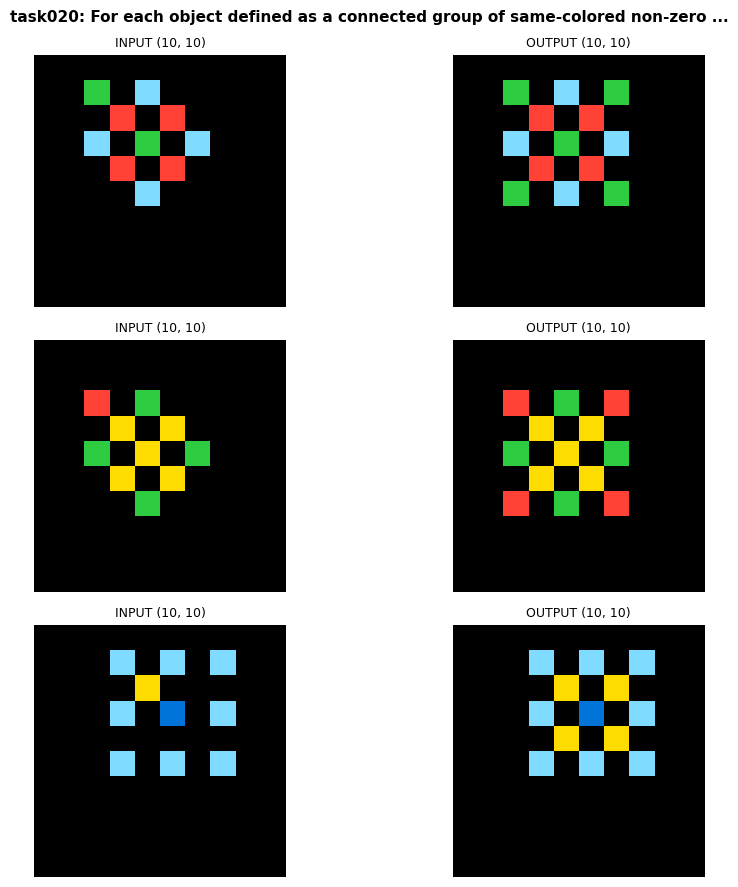

In [3]:
import json, os, numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

# --- Settings ---
START_VIS, END_VIS = 1, 20
JSON_INPUT = '/kaggle/working/arc_explanations.json'
DATASET_PATH = '/kaggle/input/competitions/neurogolf-2026' 

cmap = colors.ListedColormap(['#000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00', '#AAA', '#F012BE', '#FF851B', '#7FDBFF', '#870C25'])
norm = colors.Normalize(vmin=0, vmax=9)

with open(JSON_INPUT, 'r') as f:
    explanations = json.load(f)

for n in range(START_VIS, END_VIS + 1):
    tid = f"task{n:03d}"
    fpath = os.path.join(DATASET_PATH, f"{tid}.json")
    if not os.path.exists(fpath): continue
        
    with open(fpath, 'r') as f: 
        task_data = json.load(f)
    
    # info is now a string because you stripped 'typical' from the generator
    rule = explanations.get(tid, "No rule found.")

    # Clean Console Print
    print(f"\n{'='*20} {tid} {'='*20}")
    print(f"RULE: {rule}\n")

    # Visuals
    train = task_data['train']
    fig, axes = plt.subplots(len(train), 2, figsize=(10, 3 * len(train)))
    if len(train) == 1: axes = [axes]
    
    # Update title to use the string directly
    plt.suptitle(f"{tid}: {rule[:70]}...", fontsize=11, fontweight='bold')

    for i, pair in enumerate(train):
        for j, key in enumerate(['input', 'output']):
            grid = np.array(pair[key])
            axes[i][j].imshow(grid, cmap=cmap, norm=norm)
            axes[i][j].set_title(f"{key.upper()} {grid.shape}", fontsize=9)
            axes[i][j].axis('off')
            
    plt.tight_layout()
    plt.show()

In [4]:
import os
import sys
import json
import zipfile
import shutil
import re
import math
from pathlib import Path
from collections import Counter

import numpy as np

try:
    import onnx
    from onnx import ModelProto
except ImportError:
    os.system('pip install onnx')
    import onnx
    from onnx import ModelProto

try:
    import onnxruntime as ort
except ImportError:
    os.system('pip install onnxruntime')
    import onnxruntime as ort

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
TASK_PATTERN  = re.compile(r'^task\d{3}\.onnx$')
C, H, W       = 10, 30, 30
MAX_BYTES     = int(1.44 * 1024 * 1024)
BANNED_OPS    = {"Loop", "Scan", "NonZero", "Unique", "Script", "Function"}

# Competition task JSON files
TASK_DIR      = Path("/kaggle/input/competitions/neurogolf-2026")

# ─────────────────────────────────────────────────────────────────────────────
# ADD AS MANY SOURCES AS YOU WANT HERE
# Format: "Label": Path("...")
# ─────────────────────────────────────────────────────────────────────────────
SOLUTION_DIRS = {
    "jiweiliu": Path('/kaggle/input/notebooks/jiweiliu/kaggle-agent-ensemble-with-yash9439'),
    "hanifnoerrofiq": Path('/kaggle/input/notebooks/hanifnoerrofiq/the-epic-sax-ensembler'),
    "ashok205": Path('/kaggle/input/notebooks/ashok205/neurogolf-locally-solved'),
    #"svanikkolli": Path('/kaggle/input/notebooks/svanikkolli/neurogolf-svanik-edition'),
}

OUT_ZIP       = Path('/kaggle/working/submission.zip')
TEMP_DIR      = Path('/kaggle/working/_tmp_onnx')


# ─────────────────────────────────────────────────────────────────────────────
# ONNX LOADING from zip archives + loose files
# ─────────────────────────────────────────────────────────────────────────────
def load_from_zip(zip_path: Path) -> dict:
    graphs = {}
    try:
        with zipfile.ZipFile(zip_path, 'r') as zf:
            for entry in zf.namelist():
                basename = os.path.basename(entry)
                if TASK_PATTERN.match(basename):
                    graphs[basename] = zf.read(entry)
    except Exception as e:
        print(f"  WARNING: Could not read {zip_path.name}: {e}")
    return graphs


def load_graphs_from_dir(directory: Path, label: str) -> dict:
    graphs = {}
    if not directory.exists():
        print(f"  [{label}] directory not found: {directory}")
        return graphs
    for fpath in directory.rglob('*'):
        if fpath.is_file():
            if TASK_PATTERN.match(fpath.name):
                graphs[fpath.name] = fpath.read_bytes()
            elif fpath.suffix == '.zip':
                extracted = load_from_zip(fpath)
                if extracted:
                    print(f"  [{label}] {len(extracted)} ONNX files inside {fpath.name}")
                    for k, v in extracted.items():
                        graphs.setdefault(k, v)   # loose file takes priority
    return graphs


# ─────────────────────────────────────────────────────────────────────────────
# STATIC PROFILING (cheap pre-filter: size + banned ops)
# ─────────────────────────────────────────────────────────────────────────────
def static_check(raw_bytes: bytes) -> tuple[bool, float]:
    """Returns (passes_static, cost). cost=inf on failure."""
    if len(raw_bytes) > MAX_BYTES:
        return False, float('inf')
    model = ModelProto()
    try:
        model.ParseFromString(raw_bytes)
    except Exception:
        return False, float('inf')

    params, nbytes, tensors = 0, 0, {}
    for init in model.graph.initializer:
        dims = list(init.dims)
        p = 1
        for d in dims: p *= d
        if not dims: p = 1
        dt = init.data_type
        bpe = 4 if dt in [1,6] else (1 if dt in [2,3] else (2 if dt in [4,5] else (8 if dt in [7,11] else 4)))
        params += p
        nbytes += p * bpe
        tensors[init.name] = (p, p*bpe, dims)

    ops, macs = set(), 0
    for node in model.graph.node:
        ops.add(node.op_type)
        if node.op_type == "Conv" and len(node.input) >= 2 and node.input[1] in tensors:
            _, _, dims = tensors[node.input[1]]
            if len(dims) == 4:
                co, ci, kh, kw = dims
                macs += co * ci * kh * kw * H * W
        elif node.op_type in ("Gemm","MatMul") and len(node.input) >= 2 and node.input[1] in tensors:
            _, _, dims = tensors[node.input[1]]
            if len(dims) == 2:
                macs += dims[0] * dims[1]

    if BANNED_OPS & ops:
        return False, float('inf')

    cost = params + nbytes + macs
    return True, cost


# ─────────────────────────────────────────────────────────────────────────────
# ONNXRUNTIME VALIDATION (the crucial check the grader also performs)
# ─────────────────────────────────────────────────────────────────────────────
def encode_grid(grid: list) -> np.ndarray:
    """One-hot encode an ARC grid into [1, 10, 30, 30] float32 tensor."""
    inp = np.zeros((1, C, H, W), dtype=np.float32)
    for r, row in enumerate(grid):
        if r >= H: break
        for c, val in enumerate(row):
            if c >= W: break
            if 0 <= val < C:
                inp[0, val, r, c] = 1.0
    return inp


def validate_onnx(raw_bytes: bytes, task_data: dict) -> bool:
    try:
        opts = ort.SessionOptions()
        opts.log_severity_level = 3   # hides "Removing initializer" noise
        sess = ort.InferenceSession(
            raw_bytes,
            sess_options=opts,
            providers=['CPUExecutionProvider']
        )
        input_name = sess.get_inputs()[0].name

        for split in ('train', 'test', 'arc-gen'):
            for pair in task_data.get(split, []):
                inp = encode_grid(pair['input'])
                out = sess.run(None, {input_name: inp})[0]  # [1, 10, 30, 30]
                target = np.array(pair['output'])
                th, tw = target.shape
                pred = np.argmax(out[0, :, :th, :tw], axis=0)

                if not np.array_equal(pred, target):
                    return False
        return True
    except Exception:
        return False


# ─────────────────────────────────────────────────────────────────────────────
# LOAD TASK JSONs
# ─────────────────────────────────────────────────────────────────────────────
task_jsons = {}
if TASK_DIR.exists():
    json_files = list(TASK_DIR.glob("*.json"))
    if not json_files:
        json_files = list(TASK_DIR.rglob("*.json"))
    for jp in json_files:
        key = jp.stem + ".onnx"
        if TASK_PATTERN.match(key):
            try:
                task_jsons[key] = json.loads(jp.read_text())
            except Exception:
                pass
    print(f"Loaded {len(task_jsons)} task JSON files from {TASK_DIR}")
else:
    print(f"WARNING: Task directory not found: {TASK_DIR}")
    print("Validation will be SKIPPED — models will be accepted on static check only.")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("Neurogolf Ensembler — Multi-Source Dynamic Evaluator")
print("=" * 60)

loaded_sources = {}
all_tasks_set = set()

# Dynamically load from all provided sources
for label, dir_path in SOLUTION_DIRS.items():
    print(f"\n[{label}] loading from {dir_path}")
    graphs = load_graphs_from_dir(dir_path, label)
    print(f"  → {len(graphs)} models")
    if graphs:
        loaded_sources[label] = graphs
        all_tasks_set.update(graphs.keys())

if not loaded_sources:
    print("\nCRITICAL ERROR: No models found from any source. Attach your datasets.")
    sys.exit(1)

all_tasks = sorted(all_tasks_set)
best_graphs = {}
sources = Counter()
reasons = Counter()

print(f"\nEnsembling {len(all_tasks)} tasks across {len(loaded_sources)} sources …")
do_runtime_check = bool(task_jsons)
if not do_runtime_check:
    print("  (no task JSONs → skipping onnxruntime validation)")

for task_key in all_tasks:
    task_data = task_jsons.get(task_key)
    candidates = []

    # Iterate through all dynamically loaded datasets
    for label, store in loaded_sources.items():
        if task_key not in store:
            continue
        raw = store[task_key]

        # Step 1: static check
        ok_static, cost = static_check(raw)
        if not ok_static:
            reasons[f'{label}-static-fail'] += 1
            continue

        # Step 2: runtime check
        if do_runtime_check and task_data:
            if not validate_onnx(raw, task_data):
                reasons[f'{label}-runtime-fail'] += 1
                print(f"  [RUNTIME-FAIL] {task_key} from {label}")
                continue

        candidates.append((cost, raw, label))

    if candidates:
        candidates.sort(key=lambda x: x[0])   # lowest cost wins
        _, data, src = candidates[0]
        best_graphs[task_key] = data
        sources[src] += 1
    else:
        print(f"  [NO VALID] {task_key} — no valid model from any source")

print(f"\nFinal count : {len(best_graphs)} tasks")
print(f"Skipped     : {len(all_tasks) - len(best_graphs)} tasks")

# Dynamically print the source split
split_str = ", ".join(f"{k}={v}" for k, v in sources.items())
print(f"Source split: {split_str}")

if reasons:
    print(f"Rejection reasons: {dict(reasons)}")

# ─────────────────────────────────────────────────────────────────────────────
# PACKAGE SUBMISSION ZIP
# ─────────────────────────────────────────────────────────────────────────────
TEMP_DIR.mkdir(parents=True, exist_ok=True)

for fname, fdata in sorted(best_graphs.items()):
    (TEMP_DIR / fname).write_bytes(fdata)

with zipfile.ZipFile(OUT_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(best_graphs.keys()):
        zf.write(TEMP_DIR / fname, arcname=fname)

shutil.rmtree(TEMP_DIR)

size_kb = OUT_ZIP.stat().st_size / 1024
print(f"\nDONE!  {OUT_ZIP}  ({size_kb:.1f} KB / {MAX_BYTES/1024:.0f} KB limit)")

# Sanity check
with zipfile.ZipFile(OUT_ZIP, 'r') as zf:
    entries = zf.namelist()
    bad_paths  = [e for e in entries if '/' in e or '\\' in e]
    bad_names  = [e for e in entries if not TASK_PATTERN.match(e)]
    print(f"Sanity: {len(entries)} entries, "
          f"{len(bad_paths)} with bad paths, "
          f"{len(bad_names)} with bad names")
    if bad_paths or bad_names:
        print("  WARNING: grader may reject these entries!")
    else:
        print("  All entries look correct ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 63.0 MB/s eta 0:00:00
Loaded 400 task JSON files from /kaggle/input/competitions/neurogolf-2026
Neurogolf Ensembler — Multi-Source Dynamic Evaluator

[jiweiliu] loading from /kaggle/input/notebooks/jiweiliu/kaggle-agent-ensemble-with-yash9439
  [jiweiliu] 132 ONNX files inside submission.zip
  → 132 models

[hanifnoerrofiq] loading from /kaggle/input/notebooks/hanifnoerrofiq/the-epic-sax-ensembler
  [hanifnoerrofiq] 172 ONNX files inside submission.zip
  → 172 models

[ashok205] loading from /kaggle/input/notebooks/ashok205/neurogolf-locally-solved
  [ashok205] 160 ONNX files inside submission.zip
  → 160 models

Ensembling 204 tasks across 3 sources …

Final count : 204 tasks
Skipped     : 0 tasks
Source split: ashok205=60, jiweiliu=110, hanifnoerrofiq=34

DONE!  /kaggle/working/submission.zip  (1269.6 KB / 1475 KB limit)
Sanity: 204 entries, 0 with bad paths, 0 with bad names
  All entries look correct ✅
